<a href="https://colab.research.google.com/github/lizal04/INFO_4670_SPRING2026/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("car_purchase_data.csv")

# Preview
print(df.head())

    User ID  Gender  Age  Salary  Purchased
0  15624510    Male   19   19000          0
1  15810944    Male   35   20000          0
2  15668575  Female   26   43000          0
3  15603246  Female   27   57000          0
4  15804002    Male   19   76000          0


### Step 2: Split features and target

In [17]:
X = df[['Age', 'Salary']]
y = df['Purchased']

### Step 3: Train/Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

### Step 4: Feature Scaling

In [19]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Step 5: Train Logistic Regression Model

In [20]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

### Step 6: Predict and Evaluate

In [21]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.89
Confusion Matrix:
 [[65  3]
 [ 8 24]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



### Step 7: Visualization of Decision Regions

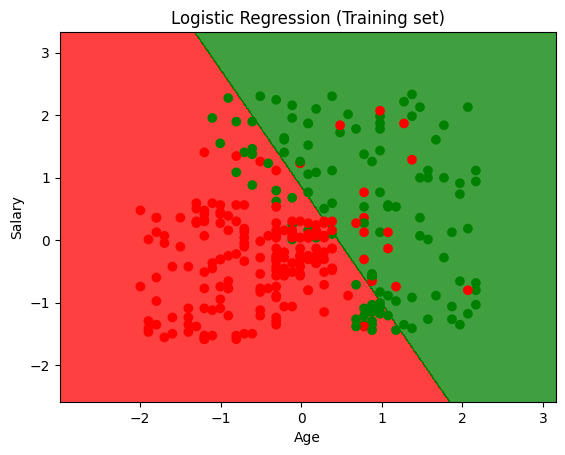

In [22]:
from matplotlib.colors import ListedColormap

X_set = X_train
y_set = y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.scatter(
    X_set[:, 0], X_set[:, 1],
    c=y_set,
    cmap=ListedColormap(('red', 'green'))
)

plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1. It gives probabilities between 0 and 1, and we use a cutoff (like 0.5) to decide the class, so it works for classification.

2. Customers who are older and have higher salaries are more likely to buy a car.

3. Low accuracy can happen if there's not enough data, only a few features, or if the data overlaps or has noise.

4. We can add more features (like gender or location), remove outliers, and tune the model.
